# Part 3 Starter Notebook

This notebook loads an AIME 2024 dataset, runs a model on each problem, extracts an AIME-style final answer, and grades the outputs.

In [14]:
import re

import pandas as pd
import torch
from datasets import load_dataset
from transformers import AutoTokenizer
from vllm import LLM, SamplingParams
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
MODEL_NAME = "Qwen/Qwen3-4B"
# or allenai/Olmo-3-7B-Thinking
DATASET_NAME = "OpenRLHF/aime-2024"
MAX_NEW_TOKENS = 1024

## Loading the model and the data

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = LLM(model=MODEL_NAME, gpu_memory_utilization=0.9, trust_remote_code=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

dataset = load_dataset(DATASET_NAME, split="train")

INFO 04-29 16:03:16 [utils.py:233] non-default args: {'trust_remote_code': True, 'disable_log_stats': True, 'model': 'Qwen/Qwen3-4B'}
INFO 04-29 16:03:17 [model.py:549] Resolved architecture: Qwen3ForCausalLM
INFO 04-29 16:03:17 [model.py:1678] Using max model len 40960
INFO 04-29 16:03:17 [scheduler.py:238] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 04-29 16:03:17 [vllm.py:790] Asynchronous scheduling is enabled.
(EngineCore pid=1040008) INFO 04-29 16:03:20 [core.py:105] Initializing a V1 LLM engine (v0.19.1) with config: model='Qwen/Qwen3-4B', speculative_config=None, tokenizer='Qwen/Qwen3-4B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=40960, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=None, enf

(EngineCore pid=1040008) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
(EngineCore pid=1040008) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


(EngineCore pid=1040008) INFO 04-29 16:03:23 [weight_utils.py:848] Prefetching checkpoint files into page cache started (in background)


Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]


(EngineCore pid=1040008) INFO 04-29 16:03:23 [weight_utils.py:825] Prefetching checkpoint files: 10% (1/3)
(EngineCore pid=1040008) INFO 04-29 16:03:24 [weight_utils.py:825] Prefetching checkpoint files: 20% (2/3)
(EngineCore pid=1040008) INFO 04-29 16:03:24 [weight_utils.py:825] Prefetching checkpoint files: 30% (3/3)


...

(EngineCore pid=1040008) INFO 04-29 16:03:24 [weight_utils.py:843] Prefetching checkpoint files into page cache finished in 0.56s


Loading safetensors checkpoint shards:  67% Completed | 2/3 [00:00<00:00,  2.31it/s]
Loading safetensors checkpoint shards: 100% Completed | 3/3 [00:00<00:00,  3.25it/s]
(EngineCore pid=1040008) 


(EngineCore pid=1040008) INFO 04-29 16:03:24 [default_loader.py:384] Loading weights took 0.93 seconds
(EngineCore pid=1040008) INFO 04-29 16:03:25 [gpu_model_runner.py:4820] Model loading took 7.56 GiB memory and 2.493513 seconds
(EngineCore pid=1040008) INFO 04-29 16:03:30 [backends.py:1051] Using cache directory: /homes/iws/kevyin30/.cache/vllm/torch_compile_cache/d895ed5373/rank_0_0/backbone for vLLM's torch.compile
(EngineCore pid=1040008) INFO 04-29 16:03:30 [backends.py:1111] Dynamo bytecode transform time: 4.70 s
(EngineCore pid=1040008) INFO 04-29 16:03:31 [backends.py:285] Directly load the compiled graph(s) for compile range (1, 8192) from the cache, took 1.180 s
(EngineCore pid=1040008) INFO 04-29 16:03:31 [decorators.py:305] Directly load AOT compilation from path /homes/iws/kevyin30/.cache/vllm/torch_compile_cache/torch_aot_compile/9b34fcef6b38a8100cde82b72579ec465212c054a6a4ddeb90ca8423c2a0398b/rank_0_0/model
(EngineCore pid=1040008) INFO 04-29 16:03:31 [monitor.py:48] t

(EngineCore pid=1040008) 2026-04-29 16:03:33,413 - INFO - autotuner.py:262 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
(EngineCore pid=1040008) 2026-04-29 16:03:33,420 - INFO - autotuner.py:268 - flashinfer.jit: [Autotuner]: Autotuning process ends
Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:01<00:00, 42.02it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:00<00:00, 54.73it/s]


(EngineCore pid=1040008) INFO 04-29 16:03:35 [gpu_model_runner.py:6046] Graph capturing finished in 2 secs, took 0.38 GiB
(EngineCore pid=1040008) INFO 04-29 16:03:35 [gpu_worker.py:597] CUDA graph pool memory: 0.38 GiB (actual), 0.54 GiB (estimated), difference: 0.16 GiB (40.6%).
(EngineCore pid=1040008) INFO 04-29 16:03:35 [core.py:283] init engine (profile, create kv cache, warmup model) took 10.75 seconds


## Evaluation helpers

In [4]:
def strip_thinking_trace(text):
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL)
    text = re.sub(
        r"<\|begin_of_thought\|>.*?<\|end_of_thought\|>", "", text, flags=re.DOTALL
    )
    return text.strip()


def extract_answer(text: str, mode="exact_match") -> int | None:
    """Extract an AIME-style integer answer from a model completion."""
    answer_text = strip_thinking_trace(text)
    if not answer_text:
        if mode == "exact_match":
            return None
        else:
            answer_text = text  # fall back to full text

    # 1. Boxed LaTeX answer: \boxed{123}
    if mode == "exact_match":
        boxed = re.findall(r"\\boxed\{(\d+)\}", answer_text)
        if boxed:
            val = int(boxed[-1])
            return val
        else:
            return None

    elif mode == "flexible_extract":
        # 2. "The answer is N" or "answer: N" patterns
        patterns = [
            r"(?:the\s+)?answer\s+is\s+[:\s]*(\d+)",
            r"answer[:\s]+(\d+)",
            r"=\s*(\d+)\s*$",
            r"(?:therefore|thus|so),?\s+(\d+)\s*(?:\.|$)",
        ]
        for pattern in patterns:
            matches = re.findall(pattern, answer_text, re.IGNORECASE)
            if matches:
                val = int(matches[-1])
                return val

        # 3. Last integer in [0, 999] in the answer portion
        integers = re.findall(r"\b(\d{1,3})\b", answer_text)
        for candidate in reversed(integers):
            val = int(candidate)
            return val
        return None

## Inference

You can also explore using vLLM to speed up inference!

In [5]:
ENABLE_THINKING = True  # Set False for no-thinking condition
ANSWER_MODE = "exact_match"

In [6]:
def build_prompt(problem, enable_thinking):
    messages = [
        {
            "role": "system",
            "content": "You are a careful competition math assistant.  Always output your final answer in \\boxed{}.",
        },
        {"role": "user", "content": problem},
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=enable_thinking,
    )


def generate_greedy(model, prompt, max_tokens=MAX_NEW_TOKENS):
    # Greedy decoding
    sampling_params = SamplingParams(max_tokens=max_tokens, temperature=0.0)

    outputs = model.generate([prompt], sampling_params)
    return outputs[0].outputs[0].text


def generate_fixed_budget(model, tokenizer, prompt, budget):
    stop_token_ids = tokenizer.convert_tokens_to_ids(["</think>", "<|im_end|>"])

    current_thinking_tokens = 0
    while current_thinking_tokens < budget:
        remaining_budget = budget - current_thinking_tokens

        # Recommended sampling parameters on model card at https://huggingface.co/Qwen/Qwen3-4B
        sampling_params = SamplingParams(
            max_tokens=remaining_budget,
            stop_token_ids=stop_token_ids,
            temperature=0.6,
            top_p=0.95,
            top_k=20,
            min_p=0.0,
        )

        outputs = model.generate([prompt], sampling_params, use_tqdm=False)
        generated_text = outputs[0].outputs[0].text
        num_generated_tokens = len(outputs[0].outputs[0].token_ids)

        prompt += generated_text
        current_thinking_tokens += num_generated_tokens

        if current_thinking_tokens < budget:
            prompt += "\nWait"
            print("INJECTING WAIT TOKEN!!!")
            current_thinking_tokens += len(
                tokenizer.encode("\nWait", add_special_tokens=False)
            )

    # prompt += "\n</think>\nThe final answer is \\boxed{"
    prompt += "\n</think>"
    print("INJECTING STOP TOKEN!!!")

    # Recommended sampling parameters on model card at https://huggingface.co/Qwen/Qwen3-4B
    final_answer_params = SamplingParams(
        max_tokens=4000,
        stop_token_ids=tokenizer.convert_tokens_to_ids(["<|im_end|>"]),
        temperature=0.6,
        top_p=0.95,
        top_k=20,
        min_p=0.0,
    )

    final_answer_outputs = model.generate([prompt], final_answer_params, use_tqdm=False)
    return prompt + final_answer_outputs[0].outputs[0].text


def generate_fixed_budget_batched(model, tokenizer, prompts, budget):
    prompts = [prompt + "<think>" for prompt in prompts]
    remaining_budget = budget - len(
        tokenizer.encode("<think>", add_special_tokens=False)
    )

    stop_token_ids = tokenizer.convert_tokens_to_ids(
        ["<think>", "</think>", "<|im_end|>"]
    )

    # Recommended sampling parameters on model card at https://huggingface.co/Qwen/Qwen3-4B
    sampling_params = SamplingParams(
        max_tokens=remaining_budget,
        stop_token_ids=stop_token_ids,
        temperature=0.6,
        top_p=0.95,
        top_k=20,
        min_p=0.0,
        min_tokens=remaining_budget,
    )

    outputs = model.generate(prompts, sampling_params)
    generated_texts = [output.outputs[0].text for output in outputs]
    prompts = [
        prompt + generated_texts[i] + "\n</think>" for i, prompt in enumerate(prompts)
    ]

    # Recommended sampling parameters on model card at https://huggingface.co/Qwen/Qwen3-4B
    final_answer_params = SamplingParams(
        max_tokens=4000,
        # stop_token_ids=tokenizer.convert_tokens_to_ids(["<|im_end|>"]),
        temperature=0.6,
        top_p=0.95,
        top_k=20,
        min_p=0.0,
    )

    final_answer_outputs = model.generate(prompts, final_answer_params)
    generated_texts = [output.outputs[0].text for output in final_answer_outputs]
    return [prompt + generated_texts[i] for i, prompt in enumerate(prompts)]


def extract_thinking(text):
    match = re.search(r"<think>(.*)", text, re.DOTALL)
    if match:
        content = match.group(1)
        if "</think>" in content:
            content = content.split("</think>")[0]
        return content
    return ""


def count_thinking_tokens(text):
    t = extract_thinking(text)
    if not t:
        return 0
    return len(tokenizer.encode(t, add_special_tokens=False))


def get_records(dataset, model_outputs, verbose=True):
    records = []

    for i, example in enumerate(dataset):
        problem = example["prompt"][0]["content"]
        gold_answer = int(example["label"])

        # model_output = outputs[i].outputs[0].text
        model_output = model_outputs[i]

        exact_extracted = extract_answer(model_output, mode="exact_match")
        flexible_extracted = extract_answer(model_output, mode="flexible_extract")
        exact_correct = (
            True
            if exact_extracted is not None and exact_extracted == gold_answer
            else False
        )
        flexible_correct = (
            True
            if flexible_extracted is not None and flexible_extracted == gold_answer
            else False
        )

        thinking_tokens = count_thinking_tokens(model_output)

        records.append(
            {
                "problem": problem,
                "gold_answer": gold_answer,
                "model_output": model_output,
                "exact_extracted": exact_extracted,
                "flexible_extracted": flexible_extracted,
                "exact_correct": exact_correct,
                "flexible_correct": flexible_correct,
                "thinking_tokens": thinking_tokens,
            }
        )

        if verbose:
            print(
                f"[{i + 1}/{len(dataset)}] gold={gold_answer} exact_pred={exact_extracted} flexible_pred={flexible_extracted} exact_correct={exact_correct} flexible_correct={flexible_correct}"
            )

    return records

In [7]:
# Build prompts for thinking and no thinking

prompts_think = [
    build_prompt(example["prompt"][0]["content"], True) for example in dataset
]
prompts_no_think = [
    build_prompt(example["prompt"][0]["content"], False) for example in dataset
]

In [ ]:
# This cell is for 2.1 warm-up. However, the next cell below has an optimized version.

records = []

for i, example in enumerate(dataset):
    if i >= 3:
        break

    problem = example["prompt"][0]["content"]
    gold_answer = int(example["label"])

    prompt = build_prompt(problem, ENABLE_THINKING)

    model_output = generate_greedy(model, prompt)

    exact_extracted = extract_answer(model_output, mode="exact_match")
    flexible_extracted = extract_answer(model_output, mode="flexible_extract")
    exact_correct = (
        True
        if exact_extracted is not None and exact_extracted == gold_answer
        else False
    )
    flexible_correct = (
        True
        if flexible_extracted is not None and flexible_extracted == gold_answer
        else False
    )

    thinking_tokens = count_thinking_tokens(model_output)

    records.append(
        {
            "problem": problem,
            "gold_answer": gold_answer,
            "model_output": model_output,
            "exact_extracted": exact_extracted,
            "flexible_extracted": flexible_extracted,
            "exact_correct": exact_correct,
            "flexible_correct": flexible_correct,
            "thinking_tokens": thinking_tokens,
        }
    )

    print(
        f"[{i + 1}/{len(dataset)}] gold={gold_answer} exact_pred={exact_extracted} flexible_pred={flexible_extracted} exact_correct={exact_correct} flexible_correct={flexible_correct}"
    )

results_df = pd.DataFrame(records)
results_df

In [ ]:
# This cell is the optimized version for 2.1 warm-up which uses batched prompts.

prompts = [
    build_prompt(example["prompt"][0]["content"], ENABLE_THINKING)
    for example in dataset
]

# Greedy decoding
sampling_params = SamplingParams(max_tokens=MAX_NEW_TOKENS, temperature=0.0)

outputs = model.generate(prompts, sampling_params)
model_outputs = [output.outputs[0].text for output in outputs]

records = get_records(dataset, model_outputs)

results_df = pd.DataFrame(records)
results_df

In [ ]:
# Save results for 2.1 warm-up

results_df.to_csv(
    f"results_df_greedy_{MAX_NEW_TOKENS}_{'think' if ENABLE_THINKING else 'no_think'}.csv",
    index=False,
)

In [ ]:
print(f"exact_correct accuracy: {results_df['exact_correct'].mean()}")
print(f"flexible_correct accuracy: {results_df['flexible_correct'].mean()}")

In [ ]:
# Generate histogram of thinking lengths

print(results_df["thinking_tokens"].describe())
results_df["thinking_tokens"].hist()
plt.title("Histogram of Thinking Lengths")
plt.xlabel("Thinking Length (tokens)")
plt.show()

In [ ]:
# This cell and the next 2 cells below can be used to incrementally generate and save results. It is not fully updated/maintained.

results_df_csv_file = "results_df_32000_v3.csv"  # Choose file to load
increment = 3  # Choose how many problems to do at a time
results_df = pd.read_csv(results_df_csv_file)
start_idx = len(results_df)
end_idx = min(start_idx + increment, len(dataset))
print(f"Resuming with start_idx: {start_idx} and end_idx: {end_idx}")

In [ ]:
new_records = []

for i in range(start_idx, end_idx):
    problem = dataset[i]["prompt"][0]["content"]
    gold_answer = int(dataset[i]["label"])

    prompt = build_prompt(problem, ENABLE_THINKING)

    model_output = generate_greedy(model, prompt)

    extracted = extract_answer(model_output, mode=ANSWER_MODE)
    if extracted is not None:
        correct = extracted == gold_answer
    else:
        correct = False

    thinking_tokens = count_thinking_tokens(model_output)

    new_records.append(
        {
            "problem": problem,
            "gold_answer": gold_answer,
            "model_output": model_output,
            "extracted_answer": extracted,
            "correct": correct,
            "thinking_tokens": thinking_tokens,
        }
    )

    print(
        f"[{i + 1}/{len(dataset)}] gold={gold_answer} pred={extracted} correct={correct}"
    )

new_df = pd.DataFrame(new_records)
results_df = pd.concat([results_df, new_df], ignore_index=True)
results_df

In [ ]:
results_df.to_csv(results_df_csv_file, index=False)
results_df["correct"].mean()

In [ ]:
# Use this cell for 2.2 scaling experiments (sequential)

thinking_budgets = [8000]

for budget in thinking_budgets:
    records = []

    for i, example in enumerate(dataset):
        if i >= 3:
            break

        problem = example["prompt"][0]["content"]
        gold_answer = int(example["label"])

        prompt = build_prompt(problem, True)

        model_output = generate_fixed_budget(model, tokenizer, prompt, budget)

        exact_extracted = extract_answer(model_output, mode="exact_match")
        flexible_extracted = extract_answer(model_output, mode="flexible_extract")
        exact_correct = (
            True
            if exact_extracted is not None and exact_extracted == gold_answer
            else False
        )
        flexible_correct = (
            True
            if flexible_extracted is not None and flexible_extracted == gold_answer
            else False
        )

        thinking_tokens = count_thinking_tokens(model_output)

        records.append(
            {
                "problem": problem,
                "gold_answer": gold_answer,
                "model_output": model_output,
                "exact_extracted": exact_extracted,
                "flexible_extracted": flexible_extracted,
                "exact_correct": exact_correct,
                "flexible_correct": flexible_correct,
                "thinking_tokens": thinking_tokens,
            }
        )

        print(
            f"[{i + 1}/{len(dataset)}] gold={gold_answer} exact_pred={exact_extracted} flexible_pred={flexible_extracted} exact_correct={exact_correct} flexible_correct={flexible_correct}"
        )

    results_df = pd.DataFrame(records)
    results_df.to_csv(f"results_df_sequential_{budget}.csv", index=False)

In [ ]:
for budget in thinking_budgets:
    print(f"budget={budget} results")
    results_df = pd.read_csv(f"results_df_sequential_{budget}.csv")
    print(f"exact_correct accuracy: {results_df['exact_correct'].mean()}")
    print(f"flexible_correct accuracy: {results_df['flexible_correct'].mean()}")
    print(results_df["thinking_tokens"].describe())

In [ ]:
# This cell is the optimized version for 2.2 sequential which uses batched prompts.

thinking_budgets = [32000]

prompts = [build_prompt(example["prompt"][0]["content"], True) for example in dataset]

for budget in thinking_budgets:
    model_outputs = generate_fixed_budget_batched(model, tokenizer, prompts, budget)

    records = get_records(dataset, model_outputs)

    results_df = pd.DataFrame(records)
    results_df.to_csv(f"results_df_sequential_{budget}.csv", index=False)

In [ ]:
for budget in thinking_budgets:
    print(f"budget={budget} results")
    results_df = pd.read_csv(f"results_df_sequential_{budget}.csv")
    print(f"exact_correct accuracy: {results_df['exact_correct'].mean()}")
    print(f"flexible_correct accuracy: {results_df['flexible_correct'].mean()}")
    print(results_df["thinking_tokens"].describe())
    print(results_df)

In [8]:
# This cell is for 2.2 parallel

parallel_budget = 4000
m = 8

for i in range(m):
    model_outputs = generate_fixed_budget_batched(
        model, tokenizer, prompts_think, parallel_budget
    )

    records = get_records(dataset, model_outputs, verbose=False)

    results_df = pd.DataFrame(records)
    results_df.to_csv(f"results_df_parallel_{i + 1}.csv", index=False)

Processed prompts: 100%|██████████| 30/30 [00:44<00:00,  1.47s/it, est. speed input: 2824.38 toks/s, output: 981.44 toks/s] 


In [ ]:
results_dfs = []

for i in range(m):
    results_dfs.append(pd.read_csv(f"results_df_parallel_{i + 1}.csv"))

combined_results_df = pd.DataFrame(
    {
        "problem": results_dfs[0]["problem"],
        "gold_answer": results_dfs[0]["gold_answer"],
        "model_output_list": list(
            zip(*[results_df["model_output"] for results_df in results_dfs])
        ),
        "exact_extracted_list": list(
            zip(*[results_df["exact_extracted"] for results_df in results_dfs])
        ),
        "flexible_extracted_list": list(
            zip(*[results_df["flexible_extracted"] for results_df in results_dfs])
        ),
        "exact_correct_list": list(
            zip(*[results_df["exact_correct"] for results_df in results_dfs])
        ),
        "flexible_correct_list": list(
            zip(*[results_df["flexible_correct"] for results_df in results_dfs])
        ),
        "thinking_tokens_list": list(
            zip(*[results_df["thinking_tokens"] for results_df in results_dfs])
        ),
    }
)

combined_results_df

,problem,gold_answer,model_output_list,exact_extracted_list,flexible_extracted_list,exact_correct_list,flexible_correct_list,thinking_tokens_list
0,Solve the following math problem step by step....,540,(<|im_start|>system\nYou are a careful competi...,"(540.0, 540.0, 540.0, 540.0, 540.0, 540.0, 540...","(540, 540, 540, 540, 540, 540, 540, 540)","(True, True, True, True, True, True, True, True)","(True, True, True, True, True, True, True, True)","(3999, 4000, 3999, 3999, 3999, 4000, 4000, 4000)"
1,Solve the following math problem step by step....,204,(<|im_start|>system\nYou are a careful competi...,"(204.0, 204.0, 204.0, 204.0, 204.0, 204.0, 204...","(204, 204, 204, 204, 204, 204, 204, 204)","(True, True, True, True, True, True, True, True)","(True, True, True, True, True, True, True, True)","(3999, 4000, 3999, 3999, 3999, 3999, 3998, 3998)"
2,Solve the following math problem step by step....,721,(<|im_start|>system\nYou are a careful competi...,"(721.0, 673.0, 721.0, 721.0, 721.0, 609.0, 337...","(721, 673, 721, 721, 721, 609, 337, 673)","(True, False, True, True, True, False, False, ...","(True, False, True, True, True, False, False, ...","(4000, 4000, 4000, 4000, 4000, 4000, 3999, 4000)"
3,Solve the following math problem step by step....,236,(<|im_start|>system\nYou are a careful competi...,"(nan, 232.0, 236.0, 236.0, nan, 302.0, 246.0, ...","(0, 232, 236, 236, 9, 302, 246, 201)","(False, False, True, True, False, False, False...","(False, False, True, True, False, False, False...","(4000, 3999, 4000, 4000, 3999, 3999, 4000, 4000)"
4,Solve the following math problem step by step....,809,(<|im_start|>system\nYou are a careful competi...,"(809.0, 578.0, 809.0, 809.0, 809.0, 1349.0, 80...","(809, 578, 809, 809, 809, 674, 809, 809)","(True, False, True, True, True, False, True, T...","(True, False, True, True, True, False, True, T...","(3999, 4000, 4000, 4000, 4000, 3999, 3999, 3999)"
5,Solve the following math problem step by step....,45,(<|im_start|>system\nYou are a careful competi...,"(100.0, 12475.0, nan, 45.0, 45.0, 45.0, 45.0, ...","(100, 4, 45, 45, 45, 45, 45, 100)","(False, False, False, True, True, True, True, ...","(False, False, True, True, True, True, True, F...","(3999, 4000, 4000, 3999, 4000, 3999, 4000, 4000)"
6,Solve the following math problem step by step....,385,(<|im_start|>system\nYou are a careful competi...,"(16.0, 16.0, nan, 24.0, 16.0, 12.0, nan, 12)","(16, 16, 3, 24, 16, 12, 1, 12)","(False, False, False, False, False, False, Fal...","(False, False, False, False, False, False, Fal...","(4000, 4000, 4000, 4000, 4000, 3999, 3999, 4000)"
7,Solve the following math problem step by step....,104,(<|im_start|>system\nYou are a careful competi...,"(80.0, nan, 107.0, 107.0, nan, nan, 107.0, 199)","(80, 2, 107, 107, 187, 905, 1, 199)","(False, False, False, False, False, False, Fal...","(False, False, False, False, False, False, Fal...","(4000, 3999, 3999, 4000, 4000, 4000, 4000, 3999)"
8,Solve the following math problem step by step....,601,(<|im_start|>system\nYou are a careful competi...,"(7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7)","(7, 7, 7, 7, 7, 7, 7, 7)","(False, False, False, False, False, False, Fal...","(False, False, False, False, False, False, Fal...","(4000, 3999, 3999, 4000, 3999, 4000, 4000, 3999)"
9,Solve the following math problem step by step....,23,(<|im_start|>system\nYou are a careful competi...,"(7.0, 43.0, 5.0, 5.0, 16.0, 5.0, 3.0, 23)","(7, 43, 5, 5, 16, 5, 3, 23)","(False, False, False, False, False, False, Fal...","(False, False, False, False, False, False, Fal...","(4000, 3999, 4000, 4000, 4000, 3999, 3999, 4000)"


In [23]:
combined_results_df.to_csv("results_df_parallel_combined.csv", index=False)

In [12]:
def majority_vote(extracted_list):
    counts = Counter(extracted_list)
    return counts.most_common(1)[0][0]


def best_of_m(correct_list):
    return any(correct_list)

In [24]:
m_vals = [1, 2, 4, 8]

results = {
    "exact_majority": [],
    "flexible_majority": [],
    "exact_best_of_m": [],
    "flexible_best_of_m": [],
}

for m_val in m_vals:
    # print("Starting m_val: ", m_val)
    exact_majority_correct = []
    flexible_majority_correct = []
    exact_best_correct = []
    flexible_best_correct = []

    for _, row in combined_results_df.iterrows():
        gold_answer = row["gold_answer"]
        # print("gold_answer: ", gold_answer)

        # Get first m completions
        exact_extracted_list = row["exact_extracted_list"][:m_val]
        flexible_extracted_list = row["flexible_extracted_list"][:m_val]
        exact_correct_list = row["exact_correct_list"][:m_val]
        flexible_correct_list = row["flexible_correct_list"][:m_val]

        # Majority vote
        exact_mv = majority_vote(exact_extracted_list)
        flexible_mv = majority_vote(flexible_extracted_list)
        exact_majority_correct.append(
            True if exact_mv is not None and exact_mv == gold_answer else False
        )
        flexible_majority_correct.append(
            True if flexible_mv is not None and flexible_mv == gold_answer else False
        )
        # print("exact_mv: ", exact_mv)
        # print("flexible_mv: ", flexible_mv)

        # Best of m
        exact_best_correct.append(best_of_m(exact_correct_list))
        flexible_best_correct.append(best_of_m(flexible_correct_list))

    results["exact_majority"].append(np.mean(exact_majority_correct))
    results["flexible_majority"].append(np.mean(flexible_majority_correct))
    results["exact_best_of_m"].append(np.mean(exact_best_correct))
    results["flexible_best_of_m"].append(np.mean(flexible_best_correct))

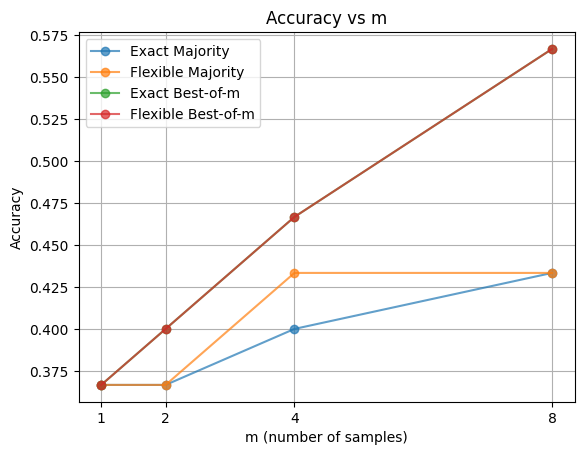

In [30]:
plt.figure()

plt.plot(
    m_vals, results["exact_majority"], marker="o", label="Exact Majority", alpha=0.7
)
plt.plot(
    m_vals,
    results["flexible_majority"],
    marker="o",
    label="Flexible Majority",
    alpha=0.7,
)
plt.plot(
    m_vals, results["exact_best_of_m"], marker="o", label="Exact Best-of-m", alpha=0.7
)
plt.plot(
    m_vals,
    results["flexible_best_of_m"],
    marker="o",
    label="Flexible Best-of-m",
    alpha=0.7,
)

plt.xlabel("m (number of samples)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs m")
plt.xticks(m_vals)
plt.legend()
plt.grid()

plt.show()

In [ ]:
# Flexible scaling plot

In [ ]:
# Cells below this are old versions that are no longer being used

In [ ]:
# New cell


def generate_with_budget_forcing(example, budget, model, tokenizer):
    # 1. Build the initial prompt using your existing template logic
    # This adds the system message, user problem, and the opening <think> tag
    prompt = build_prompt(example)

    # Identify the stop token for "end of thinking"
    # For Qwen/s1, this is usually </think> or a specific end-of-thought ID
    # stop_token_ids = tokenizer.convert_tokens_to_ids(["</think>", "<|im_end|>"])
    stop_token_ids = tokenizer.convert_tokens_to_ids(["</think>"])

    current_thinking_tokens = 0

    # 2. Sequential Scaling Loop
    while current_thinking_tokens < budget:
        remaining_budget = budget - current_thinking_tokens

        # We allow the model to generate up to the remaining budget
        # It will stop if it tries to output </think> or hits max_tokens
        sampling_params = SamplingParams(
            max_tokens=remaining_budget,
            stop_token_ids=stop_token_ids,
            temperature=0.0,
            skip_special_tokens=False,  # Keep tags so we can see them
        )

        output = model.generate([prompt], sampling_params, use_tqdm=False)[0]
        gen_text = output.outputs[0].text
        gen_tokens = len(output.outputs[0].token_ids)

        # Append the new reasoning to our prompt
        prompt += gen_text
        current_thinking_tokens += gen_tokens

        # LOGIC: Did it stop because it finished thinking or because it hit the budget?
        # If it finished early (stop reason was a stop token), inject "Wait"
        if current_thinking_tokens < budget:
            # Check if it actually emitted a stop tag; if so, we "Wait"
            # If it didn't emit a tag but stopped (rare), we still "Wait" to force length
            # prompt += " Wait,"
            prompt += "\nWait"
            # print("INJECTING WAIT TOKEN!!!")
            # current_thinking_tokens += len(tokenizer.encode(" Wait,", add_special_tokens=False))
            current_thinking_tokens += len(
                tokenizer.encode("\nWait", add_special_tokens=False)
            )

    # if prompt.endswith("</think>"):
    #     prompt = prompt[:-len("</think>")]

    if "</think>" in prompt:
        prompt = prompt.split("</think>", 1)[0]
        # print("REMOVING </think>")

    prompt += "\n</think>\n**Final Answer**\n"
    # print("INJECTING STOP TOKEN!!!")

    # Now generate the actual answer
    # We use a standard max_tokens here as the answer itself isn't part of the budget
    final_params = SamplingParams(
        max_tokens=MAX_NEW_TOKENS,
        temperature=0.0,
        stop_token_ids=tokenizer.convert_tokens_to_ids(["<|im_end|>"]),
    )

    final_output = model.generate([prompt], final_params, use_tqdm=False)[0]
    return prompt + final_output.outputs[0].text

In [ ]:
# New cell

thinking_budgets = [8000]

for budget in thinking_budgets:
    records_budget = []

    for i, example in enumerate(dataset):
        if i >= 5:
            break

        problem = example["prompt"][0]["content"]
        gold_answer = int(example["label"])

        # model_output = generate_with_budget(problem, budget, model, tokenizer)
        model_output = generate_with_budget_forcing(example, budget, model, tokenizer)

        extracted = extract_answer(model_output, mode=ANSWER_MODE)
        if extracted is not None:
            correct = extracted == gold_answer
        else:
            correct = False

        records_budget.append(
            {
                "problem": problem,
                "gold_answer": gold_answer,
                "model_output": model_output,
                "extracted_answer": extracted,
                "correct": correct,
            }
        )

        print(
            f"[{i + 1}/{len(dataset)}] gold={gold_answer} pred={extracted} correct={correct}"
        )

    results_budget_df = pd.DataFrame(records_budget)
    if ENABLE_THINKING:
        results_budget_df["thinking_tokens"] = results_budget_df["model_output"].apply(
            thinking_tokens
        )
        print(results_budget_df["thinking_tokens"].describe())
        results_budget_df["thinking_tokens"].hist()
        plt.title("Histogram of Thinking Lengths")
        plt.xlabel("Thinking Length (tokens)")
        plt.show()
    results_budget_df.to_csv(f"results_budget_{budget}_v2_df.csv", index=False)
    print(results_budget_df["correct"].mean())